<a href="https://colab.research.google.com/github/rai-ritvik/OmniScan/blob/face_detection%26recognition/Face_Attendance_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Attendance ML

ML-only notebook for face enrollment and live attendance verification.

Scope:
- face detection and quality checks
- ArcFace embeddings (InsightFace `buffalo_l`)
- 3–5 frame enrollment
- blink challenge with MediaPipe Face Landmarker
- optional RGB liveness hook
- face verification using cosine similarity
- offline threshold calibration and held-out testing

The notebook does not handle frontend UI, PostgreSQL, attendance records, or backend business rules.

In [1]:
# Cell 1 — Install dependencies

!pip -q install \
    insightface \
    "onnx==1.20.1" \
    onnxruntime \
    mediapipe \
    numpy \
    pandas \
    matplotlib \
    opencv-python-headless

print("Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.0 MB/s eta 0:00:00
Dependencies installed


In [2]:
# Cell 2 — Imports and configuration (BETTER VERSION)

import os
import json
import base64
import random
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Javascript
from google.colab.output import eval_js

from insightface.app import FaceAnalysis


@dataclass
class MLConfig:

    # --------------------------------------------------
    # FACE VERIFICATION
    # --------------------------------------------------

    # Provisional threshold.
    # Final value is recalculated by calibration below.
    face_threshold: float = 0.50

    # Don't let calibration choose an unusually low threshold.
    # MUST still be validated with your real deployment camera.
    minimum_deployment_threshold: float = 0.50

    # --------------------------------------------------
    # ENROLLMENT
    # --------------------------------------------------

    registration_min_frames: int = 3
    registration_max_frames: int = 8
    registration_target_frames: int = 5

    # Checks whether enrollment images are sufficiently
    # consistent with each other.
    enrollment_min_coherence: float = 0.45

    # --------------------------------------------------
    # ATTENDANCE
    # --------------------------------------------------

    attendance_min_frames: int = 20
    attendance_max_frames: int = 60

    # Number of identity frames actually used.
    verification_target_frames: int = 8

    # Minimum number of usable face frames.
    verification_min_good_frames: int = 5

    # Percentage of selected frames that must pass.
    verification_min_pass_ratio: float = 0.75

    # --------------------------------------------------
    # FACE QUALITY
    # --------------------------------------------------

    min_face_area_ratio: float = 0.03
    min_blur_variance: float = 40.0

    # --------------------------------------------------
    # BLINK / LIVENESS CHALLENGE
    # --------------------------------------------------

    blink_min_observations: int = 10
    blink_baseline_frames: int = 10

    # Both eyes must remain closed for at least this many frames.
    blink_min_closed_frames: int = 2

    # Both eyes must reopen for at least this many frames.
    blink_min_reopen_frames: int = 2

    # Absolute minimum eye-blink score to count as closure.
    blink_close_floor: float = 0.45

    # Adaptive amount above the user's baseline.
    blink_close_delta: float = 0.20

    # Reopen threshold relative to baseline.
    blink_reopen_delta: float = 0.05


CONFIG = MLConfig()

MODEL_NAME = "buffalo_l"
MODEL_VERSION = "face-v1"
EXPECTED_EMBEDDING_DIM = 512


# --------------------------------------------------
# MODEL DIRECTORY
# --------------------------------------------------

MODEL_DIR = Path("/content/face_attendance_ml")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------
# MEDIAPIPE MODEL
# --------------------------------------------------

MEDIA_PIPE_MODEL = MODEL_DIR / "face_landmarker.task"

MEDIA_PIPE_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
)


# --------------------------------------------------
# DATASET
# --------------------------------------------------

# For your current dataset.zip:
DATASET_MODE = "full"

# Allowed:
#   "full"    -> normal full images
#   "cropped" -> already cropped faces

DATASET_WORK_DIR = Path(
    "/content/face_attendance_datasets"
)

DATASET_WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

IGNORED_DIR_NAMES = {
    "__MACOSX",
    ".git",
    "__pycache__"
}


print("✅ Better configuration loaded")
print("Face threshold:", CONFIG.face_threshold)
print("Verification frames:", CONFIG.verification_target_frames)
print("Verification pass ratio:", CONFIG.verification_min_pass_ratio)
print("Dataset mode:", DATASET_MODE)

✅ Better configuration loaded
Face threshold: 0.5
Verification frames: 8
Verification pass ratio: 0.75
Dataset mode: full


In [3]:
# Cell 3 — Load InsightFace

face_app = FaceAnalysis(
    name=MODEL_NAME,
    providers=["CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=-1,
    det_size=(640, 640)
)

print(f"{MODEL_NAME} loaded")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:06<00:00, 46574.32KB/s]


buffalo_l loaded


In [4]:
# Cell 4 — Load MediaPipe Face Landmarker

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

if not MEDIA_PIPE_MODEL.exists():
    urllib.request.urlretrieve(
        MEDIA_PIPE_URL,
        MEDIA_PIPE_MODEL
    )

base_options = python.BaseOptions(
    model_asset_path=str(MEDIA_PIPE_MODEL)
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True
)

blink_landmarker = vision.FaceLandmarker.create_from_options(options)

print("MediaPipe Face Landmarker loaded")

MediaPipe Face Landmarker loaded


In [5]:
# Cell 5 — Core face functions

def normalize_embedding(embedding):
    embedding = np.asarray(embedding, dtype=np.float32)
    norm = np.linalg.norm(embedding)
    if norm <= 0:
        raise ValueError("Invalid zero embedding")
    return embedding / norm


def extract_face_embedding(image):
    faces = face_app.get(image)

    if len(faces) == 0:
        raise ValueError("No face detected")
    if len(faces) != 1:
        raise ValueError(f"Expected exactly one face; found {len(faces)}")

    embedding = getattr(faces[0], "normed_embedding", None)
    if embedding is None:
        raise ValueError("Embedding was not produced")

    embedding = normalize_embedding(embedding)

    if embedding.size != EXPECTED_EMBEDDING_DIM:
        raise ValueError(
            f"Embedding dimension {embedding.size} != {EXPECTED_EMBEDDING_DIM}"
        )

    return embedding, faces[0]


def assess_face_quality(image, face):
    h, w = image.shape[:2]
    box = np.asarray(face.bbox, dtype=np.float32)

    face_w = max(0.0, float(box[2] - box[0]))
    face_h = max(0.0, float(box[3] - box[1]))
    area_ratio = face_w * face_h / max(1.0, float(w * h))

    x1 = max(0, int(box[0]))
    y1 = max(0, int(box[1]))
    x2 = min(w, int(box[2]))
    y2 = min(h, int(box[3]))

    crop = image[y1:y2, x1:x2]
    blur_variance = 0.0
    if crop.size:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        blur_variance = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    usable = (
        area_ratio >= CONFIG.min_face_area_ratio
        and blur_variance >= CONFIG.min_blur_variance
    )

    return {
        "usable": bool(usable),
        "area_ratio": float(area_ratio),
        "blur_variance": float(blur_variance),
        "quality_score": float(
            0.55 * min(area_ratio / max(CONFIG.min_face_area_ratio * 4, 1e-6), 1.0)
            + 0.45 * min(blur_variance / 150.0, 1.0)
        )
    }


def cosine_similarity(a, b):
    return float(np.dot(normalize_embedding(a), normalize_embedding(b)))


print("Face functions ready")

Face functions ready


In [6]:
# Cell 6 — BETTER Blink / Liveness Challenge


def get_blink_score(image):
    """
    Extract both-eye blink scores from one BGR image.
    MediaPipe is running in IMAGE mode.
    """

    if image is None:
        return None

    if not isinstance(image, np.ndarray):
        return None

    try:
        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = blink_landmarker.detect(
            mp_image
        )

        if not result.face_blendshapes:
            return None

        if not result.face_landmarks:
            return None

        scores = {
            item.category_name: float(item.score)
            for item in result.face_blendshapes[0]
        }

        left = scores.get("eyeBlinkLeft")
        right = scores.get("eyeBlinkRight")

        if left is None or right is None:
            return None

        return {
            "left": float(left),
            "right": float(right),
            "mean": float(
                (left + right) / 2.0
            )
        }

    except Exception:
        return None


def smooth_signal(values, window=3):
    """
    Smooth a signal while keeping the same length.
    """

    values = np.asarray(
        values,
        dtype=np.float32
    )

    if len(values) < window:
        return values

    kernel = (
        np.ones(window, dtype=np.float32)
        / window
    )

    return np.convolve(
        values,
        kernel,
        mode="same"
    )


def detect_blink_mediapipe(frames):
    """
    Detect one complete blink sequence:

        OPEN
          ↓
        CLOSED
          ↓
        OPEN

    Both eyes must participate.
    """

    observations = []

    for index, frame in enumerate(frames):

        value = get_blink_score(frame)

        if value is None:
            continue

        observations.append({
            "index": index,
            "left": value["left"],
            "right": value["right"],
            "mean": value["mean"]
        })


    # --------------------------------------------------
    # Not enough observations
    # --------------------------------------------------

    if len(observations) < CONFIG.blink_min_observations:

        return {
            "blink_detected": False,
            "reason": "Insufficient blink observations",
            "valid_observations": len(observations),
            "max_score": 0.0,
            "scores": []
        }


    left = np.asarray(
        [x["left"] for x in observations],
        dtype=np.float32
    )

    right = np.asarray(
        [x["right"] for x in observations],
        dtype=np.float32
    )

    mean = np.asarray(
        [x["mean"] for x in observations],
        dtype=np.float32
    )


    # --------------------------------------------------
    # Personal baseline
    # --------------------------------------------------

    baseline_count = min(
        CONFIG.blink_baseline_frames,
        max(
            5,
            len(mean)
            - CONFIG.blink_min_closed_frames
            - CONFIG.blink_min_reopen_frames
        )
    )

    baseline = float(
        np.median(
            mean[:baseline_count]
        )
    )


    close_threshold = max(
        CONFIG.blink_close_floor,
        baseline
        + CONFIG.blink_close_delta
    )

    reopen_threshold = max(
        0.15,
        baseline
        + CONFIG.blink_reopen_delta
    )


    # --------------------------------------------------
    # Smooth signals
    # --------------------------------------------------

    left_s = smooth_signal(
        left,
        window=3
    )

    right_s = smooth_signal(
        right,
        window=3
    )


    # --------------------------------------------------
    # State machine
    # --------------------------------------------------

    seen_open = False

    open_run = 0
    closed_run = 0
    reopen_run = 0

    closure_start = None
    closure_end = None

    peak_score = 0.0


    for i in range(
        baseline_count,
        len(mean)
    ):

        both_open = (
            left_s[i] <= reopen_threshold
            and
            right_s[i] <= reopen_threshold
        )

        both_closed = (
            left_s[i] >= close_threshold
            and
            right_s[i] >= close_threshold
        )


        peak_score = max(
            peak_score,
            float(
                (left_s[i] + right_s[i]) / 2.0
            )
        )


        # ==================================================
        # BEFORE CLOSURE
        # ==================================================

        if closure_start is None:

            # Look for clearly open eyes first.
            if both_open:

                open_run += 1

                if (
                    open_run
                    >= CONFIG.blink_min_reopen_frames
                ):
                    seen_open = True

            else:
                open_run = 0


            # Look for actual bilateral eye closure.
            if (
                seen_open
                and
                both_closed
            ):

                closed_run += 1

                if (
                    closed_run
                    >= CONFIG.blink_min_closed_frames
                ):

                    closure_start = (
                        i
                        - CONFIG.blink_min_closed_frames
                        + 1
                    )

                    closure_end = i

                    reopen_run = 0

            else:
                closed_run = 0


        # ==================================================
        # AFTER CLOSURE
        # ==================================================

        else:

            if both_open:

                reopen_run += 1

                # Complete OPEN -> CLOSED -> OPEN.
                if (
                    reopen_run
                    >= CONFIG.blink_min_reopen_frames
                ):

                    return {

                        "blink_detected": True,

                        "reason": None,

                        "valid_observations":
                            len(observations),

                        "baseline":
                            round(baseline, 4),

                        "close_threshold":
                            round(close_threshold, 4),

                        "reopen_threshold":
                            round(reopen_threshold, 4),

                        "max_score":
                            round(
                                float(
                                    max(
                                        peak_score,
                                        np.max(mean)
                                    )
                                ),
                                4
                            ),

                        "closure_start":
                            closure_start,

                        "closure_end":
                            closure_end,

                        "recovery_index":
                            i,

                        "scores":
                            [
                                float(x)
                                for x in mean
                            ]
                    }

            else:
                reopen_run = 0


    # --------------------------------------------------
    # No complete blink
    # --------------------------------------------------

    return {

        "blink_detected": False,

        "reason":
            "No complete open-close-open blink sequence detected",

        "valid_observations":
            len(observations),

        "baseline":
            round(baseline, 4),

        "close_threshold":
            round(close_threshold, 4),

        "reopen_threshold":
            round(reopen_threshold, 4),

        "max_score":
            round(
                float(np.max(mean)),
                4
            ),

        "closure_start":
            closure_start,

        "closure_end":
            closure_end,

        "recovery_index":
            None,

        "scores":
            [
                float(x)
                for x in mean
            ]
    }


print("✅ Better blink detector ready")

✅ Better blink detector ready


In [7]:
# Cell 7 — Local template store for notebook testing

class InMemoryTemplateStore:
    def __init__(self):
        self._items = {}

    def save(self, student_id, full_name, embedding, samples_used):
        self._items[str(student_id)] = {
            "student_id": str(student_id),
            "full_name": str(full_name),
            "embedding": normalize_embedding(embedding),
            "samples_used": int(samples_used)
        }

    def get(self, student_id):
        key = str(student_id)
        if key not in self._items:
            raise KeyError(f"No template found for student ID {key}")
        return self._items[key]

    def clear(self):
        self._items.clear()


template_store = InMemoryTemplateStore()
print("Template store ready")

Template store ready


In [8]:
# Cell 8 — BETTER Multi-Frame Enrollment


def select_temporally_distributed(
    candidates,
    target_count
):
    """
    Select good-quality frames from different
    parts of the sequence instead of taking all
    best frames from one short moment.
    """

    if not candidates:
        return []

    candidates = sorted(
        candidates,
        key=lambda x: x["index"]
    )

    target_count = min(
        int(target_count),
        len(candidates)
    )

    if len(candidates) <= target_count:

        return sorted(
            candidates,
            key=lambda x:
                x["quality"]["quality_score"],
            reverse=True
        )


    selected = []

    bins = np.array_split(
        np.arange(len(candidates)),
        target_count
    )


    for bin_indices in bins:

        if len(bin_indices) == 0:
            continue

        pool = [
            candidates[int(i)]
            for i in bin_indices
        ]

        best = max(
            pool,
            key=lambda x:
                x["quality"]["quality_score"]
        )

        selected.append(best)


    return sorted(
        selected,
        key=lambda x: x["index"]
    )


def enroll_student_from_frames(
    student_id,
    full_name,
    frames
):

    if not isinstance(
        frames,
        (list, tuple)
    ):
        raise TypeError(
            "frames must be a list/tuple of BGR images"
        )


    if not (
        CONFIG.registration_min_frames
        <= len(frames)
        <= CONFIG.registration_max_frames
    ):

        raise ValueError(
            f"Send between "
            f"{CONFIG.registration_min_frames} "
            f"and "
            f"{CONFIG.registration_max_frames} "
            f"frames"
        )


    candidates = []


    # --------------------------------------------------
    # Extract usable frames
    # --------------------------------------------------

    for index, frame in enumerate(frames):

        try:

            embedding, face = (
                extract_face_embedding(frame)
            )

            quality = (
                assess_face_quality(
                    frame,
                    face
                )
            )

            if quality["usable"]:

                candidates.append({

                    "index": index,

                    "embedding":
                        embedding,

                    "quality":
                        quality

                })

        except Exception:
            continue


    if len(candidates) < (
        CONFIG.registration_min_frames
    ):

        raise ValueError(

            f"Only "
            f"{len(candidates)} "
            f"usable frames found. "

            f"Need at least "
            f"{CONFIG.registration_min_frames}."
        )


    # --------------------------------------------------
    # Select distributed good frames
    # --------------------------------------------------

    selected = (
        select_temporally_distributed(
            candidates,
            CONFIG.registration_target_frames
        )
    )


    # --------------------------------------------------
    # Create reference embedding
    # --------------------------------------------------

    reference = normalize_embedding(

        np.mean(

            np.stack(
                [
                    item["embedding"]
                    for item in selected
                ]
            ),

            axis=0
        )
    )


    # --------------------------------------------------
    # Enrollment consistency
    # --------------------------------------------------

    coherence_scores = [

        cosine_similarity(
            item["embedding"],
            reference
        )

        for item in selected
    ]


    coherence_median = float(
        np.median(
            coherence_scores
        )
    )


    if (
        coherence_median
        < CONFIG.enrollment_min_coherence
    ):

        raise ValueError(

            "Enrollment frames are not "
            "sufficiently consistent. "

            "Please keep one person's face "
            "centered and register again."
        )


    return {

        "success": True,

        "student_id":
            str(student_id),

        "full_name":
            str(full_name).strip(),

        "samples_received":
            len(frames),

        "samples_used":
            len(selected),

        "embedding_dimension":
            int(reference.size),

        "reference_embedding":
            reference,

        "enrollment_coherence_median":
            round(
                coherence_median,
                4
            ),

        "selected_frame_indices":
            [
                int(
                    item["index"]
                )
                for item in selected
            ]
    }


print("✅ Better enrollment ready")

✅ Better enrollment ready


In [9]:
# Cell 9 — BETTER Multi-Frame Attendance Verification


def verify_scores_against_template(
    scores,
    threshold
):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )


    if scores.size == 0:

        return {

            "verified": False,

            "median_similarity": None,

            "mean_similarity": None,

            "min_similarity": None,

            "pass_ratio": 0.0,

            "passed_frames": 0,

            "total_frames": 0
        }


    passed_frames = int(
        np.sum(
            scores >= threshold
        )
    )


    total_frames = len(scores)


    pass_ratio = (
        passed_frames
        / total_frames
    )


    median_similarity = float(
        np.median(scores)
    )


    mean_similarity = float(
        np.mean(scores)
    )


    min_similarity = float(
        np.min(scores)
    )


    verified = (

        median_similarity
        >= threshold

        and

        pass_ratio
        >= CONFIG.verification_min_pass_ratio
    )


    return {

        "verified":
            bool(verified),

        "median_similarity":
            median_similarity,

        "mean_similarity":
            mean_similarity,

        "min_similarity":
            min_similarity,

        "pass_ratio":
            float(pass_ratio),

        "passed_frames":
            passed_frames,

        "total_frames":
            total_frames
    }


def verify_attendance_from_frames(
    student_id,
    frames
):

    # --------------------------------------------------
    # Retrieve registered template
    # --------------------------------------------------

    try:

        template = (
            template_store.get(
                student_id
            )
        )

    except KeyError:

        return {

            "verified": False,

            "student_id":
                str(student_id),

            "full_name":
                None,

            "similarity":
                None,

            "threshold":
                float(
                    CONFIG.face_threshold
                ),

            "blink_detected":
                False,

            "reason":
                "Template not found"
        }


    # --------------------------------------------------
    # Validate frames
    # --------------------------------------------------

    if not isinstance(
        frames,
        (list, tuple)
    ):

        return {

            "verified": False,

            "student_id":
                str(student_id),

            "full_name":
                template["full_name"],

            "similarity":
                None,

            "threshold":
                float(
                    CONFIG.face_threshold
                ),

            "blink_detected":
                False,

            "reason":
                "frames must be a list/tuple"
        }


    if not (
        CONFIG.attendance_min_frames
        <= len(frames)
        <= CONFIG.attendance_max_frames
    ):

        return {

            "verified": False,

            "student_id":
                str(student_id),

            "full_name":
                template["full_name"],

            "similarity":
                None,

            "threshold":
                float(
                    CONFIG.face_threshold
                ),

            "blink_detected":
                False,

            "reason":
                "Invalid attendance frame count"
        }


    # --------------------------------------------------
    # Blink challenge
    # --------------------------------------------------

    blink = (
        detect_blink_mediapipe(
            frames
        )
    )


    if not blink["blink_detected"]:

        return {

            "verified": False,

            "student_id":
                str(student_id),

            "full_name":
                template["full_name"],

            "similarity":
                None,

            "threshold":
                float(
                    CONFIG.face_threshold
                ),

            "blink_detected":
                False,

            "liveness": {

                "enabled":
                    True,

                "passed":
                    False,

                "method":
                    "blink_challenge",

                "status":
                    "failed",

                "reason":
                    blink.get(
                        "reason"
                    )
            },

            "reason":
                "Blink challenge failed"
        }


    # --------------------------------------------------
    # Detect usable face frames
    # --------------------------------------------------

    candidates = []


    for index, frame in enumerate(frames):

        try:

            embedding, face = (
                extract_face_embedding(
                    frame
                )
            )

            quality = (
                assess_face_quality(
                    frame,
                    face
                )
            )


            if quality["usable"]:

                candidates.append({

                    "index":
                        index,

                    "embedding":
                        embedding,

                    "quality":
                        quality
                })


        except Exception:
            continue


    # --------------------------------------------------
    # Enough good frames?
    # --------------------------------------------------

    if len(candidates) < (
        CONFIG.verification_min_good_frames
    ):

        return {

            "verified": False,

            "student_id":
                str(student_id),

            "full_name":
                template["full_name"],

            "similarity":
                None,

            "threshold":
                float(
                    CONFIG.face_threshold
                ),

            "blink_detected":
                True,

            "liveness": {

                "enabled":
                    True,

                "passed":
                    True,

                "method":
                    "blink_challenge",

                "status":
                    "ok"
            },

            "reason":
                (
                    f"Only "
                    f"{len(candidates)} "
                    f"usable face frames found. "

                    f"Need at least "
                    f"{CONFIG.verification_min_good_frames}."
                )
        }


    # --------------------------------------------------
    # Select temporally distributed frames
    # --------------------------------------------------

    selected = (
        select_temporally_distributed(
            candidates,
            CONFIG.verification_target_frames
        )
    )


    # --------------------------------------------------
    # Compare every selected frame
    # --------------------------------------------------

    scores = [

        cosine_similarity(
            template["embedding"],
            item["embedding"]
        )

        for item in selected
    ]


    # --------------------------------------------------
    # Aggregate decision
    # --------------------------------------------------

    decision = (
        verify_scores_against_template(
            scores,
            CONFIG.face_threshold
        )
    )


    return {

        "verified":
            decision["verified"],

        "student_id":
            str(student_id),

        "full_name":
            template["full_name"],

        # Median is the main reported score
        # because it is less sensitive to outliers.
        "similarity":
            round(
                decision[
                    "median_similarity"
                ],
                4
            ),

        "mean_similarity":
            round(
                decision[
                    "mean_similarity"
                ],
                4
            ),

        "min_similarity":
            round(
                decision[
                    "min_similarity"
                ],
                4
            ),

        "threshold":
            float(
                CONFIG.face_threshold
            ),

        "passed_frames":
            decision[
                "passed_frames"
            ],

        "verified_pass_ratio":
            round(
                decision[
                    "pass_ratio"
                ],
                4
            ),

        "frames_used_for_identity":
            decision[
                "total_frames"
            ],

        "selected_frame_indices":
            [
                int(
                    item["index"]
                )
                for item in selected
            ],

        "blink_detected":
            True,

        "liveness": {

            "enabled":
                True,

            "passed":
                True,

            "method":
                "blink_challenge",

            "status":
                "ok",

            "blink_peak_score":
                round(
                    float(
                        blink.get(
                            "max_score",
                            0.0
                        )
                    ),
                    4
                )
        },

        "reason":
            (
                None
                if decision["verified"]
                else
                "Multi-frame face verification failed"
            )
    }


print("✅ Better attendance verification ready")

✅ Better attendance verification ready


In [10]:
# Cell 10 — Colab camera helper (testing only)

def camera_capture(num_frames, interval_ms, instruction):
    js = r"""
    async function cameraCapture(args) {
        const box = document.createElement("div");
        box.style.padding = "12px";
        box.style.border = "1px solid #bbb";
        box.style.borderRadius = "10px";
        box.style.display = "inline-block";
        box.style.fontFamily = "Arial, sans-serif";

        const title = document.createElement("div");
        title.textContent = args.instruction;
        title.style.fontSize = "20px";
        title.style.fontWeight = "600";
        title.style.marginBottom = "8px";

        const status = document.createElement("div");
        status.textContent = "Requesting camera permission...";
        status.style.marginBottom = "8px";

        const video = document.createElement("video");
        video.autoplay = true;
        video.muted = true;
        video.setAttribute("playsinline", "");
        video.style.width = "640px";
        video.style.maxWidth = "90vw";
        video.style.display = "block";

        const counter = document.createElement("div");
        counter.style.marginTop = "8px";

        box.appendChild(title);
        box.appendChild(status);
        box.appendChild(video);
        box.appendChild(counter);
        document.body.appendChild(box);

        let stream = null;
        try {
            stream = await navigator.mediaDevices.getUserMedia({
                video: { width: { ideal: 640 }, height: { ideal: 480 }, facingMode: "user" },
                audio: false
            });

            video.srcObject = stream;
            await video.play();
            status.textContent = "Camera ready.";
            await new Promise(r => setTimeout(r, 1200));

            const canvas = document.createElement("canvas");
            canvas.width = video.videoWidth || 640;
            canvas.height = video.videoHeight || 480;
            const ctx = canvas.getContext("2d");
            const frames = [];

            for (let i = 0; i < args.num_frames; i++) {
                counter.textContent = `Frame ${i + 1} / ${args.num_frames}`;
                ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
                frames.push(canvas.toDataURL("image/jpeg", 0.82));
                await new Promise(r => setTimeout(r, args.interval_ms));
            }

            return frames;
        } finally {
            if (stream) stream.getTracks().forEach(track => track.stop());
            box.remove();
        }
    }
    """

    display(Javascript(js))
    args = {
        "num_frames": int(num_frames),
        "interval_ms": int(interval_ms),
        "instruction": instruction
    }

    return eval_js("cameraCapture(" + json.dumps(args) + ")")


def data_url_to_bgr(data_url):
    raw = base64.b64decode(data_url.split(",", 1)[1])
    image = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("Invalid camera frame")
    return image


def camera_frames_to_images(data_urls):
    return [data_url_to_bgr(item) for item in data_urls]


print("Camera helper ready")

Camera helper ready


## Dataset calibration

The calibration dataset is used only to estimate a starting face threshold. The final threshold should be rechecked using real society-camera images before deployment.

In [11]:
# CELL 11 — Upload ANY dataset ZIP(s)

from google.colab import files
import shutil
import zipfile
from pathlib import Path


def upload_any_datasets():

    print("Upload one or more ZIP datasets.")
    print()
    print("Examples:")
    print("  dataset.zip")
    print("  society_members.zip")
    print("  another_face_dataset.zip")
    print()

    uploaded = files.upload()

    if not uploaded:
        raise RuntimeError(
            "No dataset uploaded."
        )

    extracted_roots = []

    for filename in uploaded.keys():

        zip_path = Path("/content") / filename

        dataset_name = Path(filename).stem

        extract_root = (
            DATASET_WORK_DIR /
            dataset_name
        )

        if extract_root.exists():
            shutil.rmtree(
                extract_root
            )

        extract_root.mkdir(
            parents=True,
            exist_ok=True
        )

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            z.extractall(
                extract_root
            )

        extracted_roots.append(
            extract_root
        )

        print(
            f"✅ Extracted: {filename}"
        )

        print(
            f"   → {extract_root}"
        )

    return extracted_roots


def discover_identity_folders(
    roots
):

    identity_paths = {}

    for root in roots:

        for directory in root.rglob("*"):

            if not directory.is_dir():
                continue

            if (
                directory.name.startswith(".")
                or
                directory.name in IGNORED_DIR_NAMES
            ):
                continue

            image_files = [
                p
                for p in directory.iterdir()
                if (
                    p.is_file()
                    and
                    p.suffix.lower()
                    in IMAGE_EXTENSIONS
                    and
                    not p.name.startswith(".")
                )
            ]

            if not image_files:
                continue

            # The directory containing the images
            # is treated as the identity folder.
            identity = directory.name

            identity_paths.setdefault(
                identity,
                []
            ).extend(
                sorted(image_files)
            )

    # Remove duplicate paths.
    for identity in identity_paths:

        identity_paths[identity] = list(
            dict.fromkeys(
                identity_paths[identity]
            )
        )

    return identity_paths


DATASET_ROOTS = upload_any_datasets()

IDENTITY_IMAGE_PATHS = (
    discover_identity_folders(
        DATASET_ROOTS
    )
)

if not IDENTITY_IMAGE_PATHS:

    raise RuntimeError(
        "❌ No identity folders containing "
        "images were found."
    )

print()
print(
    "✅ Dataset discovery successful"
)

print(
    "ZIP datasets:",
    len(DATASET_ROOTS)
)

print(
    "Identity folders:",
    len(IDENTITY_IMAGE_PATHS)
)

print(
    "Images found:",
    sum(
        len(v)
        for v in
        IDENTITY_IMAGE_PATHS.values()
    )
)

Upload one or more ZIP datasets.

Examples:
  dataset.zip
  society_members.zip
  another_face_dataset.zip



Saving dataset.zip to dataset.zip
✅ Extracted: dataset.zip
   → /content/face_attendance_datasets/dataset

✅ Dataset discovery successful
ZIP datasets: 1
Identity folders: 13
Images found: 533


In [12]:
# Cell 12 — Dataset inventory (works with any discovered dataset)

def dataset_inventory(identity_image_paths):
    rows = []

    for identity in sorted(identity_image_paths):
        image_paths = identity_image_paths[identity]

        rows.append({
            "identity": identity,
            "images": len(image_paths)
        })

    return pd.DataFrame(rows)


inventory_df = dataset_inventory(
    IDENTITY_IMAGE_PATHS
)

if inventory_df.empty:
    raise RuntimeError(
        "❌ No identities/images found in the dataset."
    )

display(inventory_df)

print(
    "Identities:",
    len(inventory_df)
)

print(
    "Total images:",
    int(inventory_df["images"].sum())
)

print(
    "Minimum images per identity:",
    int(inventory_df["images"].min())
)

print(
    "Maximum images per identity:",
    int(inventory_df["images"].max())
)

,identity,images
0,ben_afflek,14
1,elton_john,17
2,jasprit_bumrah,50
3,jay_shah,17
4,jerry_seinfeld,21
5,karan,21
6,lionel_messi,53
7,madonna,19
8,maria_sharapova,76
9,mindy_kaling,22


Identities: 13
Total images: 533
Minimum images per identity: 14
Maximum images per identity: 104


In [13]:
# Cell 13 — Dataset-independent embedding extraction
#
# Supports:
#   "full"    -> normal images; detect exactly one face first
#   "cropped" -> images are already face-cropped; use ArcFace directly
#
# The dataset name/file name does NOT matter.
#
# IMPORTANT:
# For your current dataset.zip, use:
# DATASET_MODE = "full"
#
# For cropped face datasets, use:
# DATASET_MODE = "cropped"

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}


def extract_cropped_face_embedding(image):
    """
    Extract ArcFace embedding from an image that is already
    cropped around a single face.
    """

    if image is None:
        raise ValueError("Image is None")

    # Convert grayscale to BGR
    if len(image.shape) == 2:
        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2BGR
        )

    if len(image.shape) != 3 or image.shape[2] != 3:
        raise ValueError(
            "Expected a 3-channel BGR image"
        )

    h, w = image.shape[:2]

    if min(h, w) < 50:
        raise ValueError(
            f"Face image too small: {w}x{h}"
        )

    recognition_model = face_app.models.get(
        "recognition"
    )

    if recognition_model is None:
        raise RuntimeError(
            "InsightFace recognition model not found"
        )

    embedding = (
        recognition_model
        .get_feat(image)
        .flatten()
    )

    embedding = normalize_embedding(
        embedding
    )

    if embedding.size != EXPECTED_EMBEDDING_DIM:
        raise ValueError(
            f"Embedding dimension {embedding.size} "
            f"!= expected {EXPECTED_EMBEDDING_DIM}"
        )

    return embedding


def assess_cropped_image_quality(image):
    """
    Basic quality check for an already-cropped face image.
    """

    h, w = image.shape[:2]

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    blur_variance = float(
        cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()
    )

    min_dimension = min(h, w)

    size_ok = (
        min_dimension >= 50
    )

    blur_ok = (
        blur_variance >= 10.0
    )

    size_score = min(
        min_dimension / 112.0,
        1.0
    )

    blur_score = min(
        blur_variance / 100.0,
        1.0
    )

    quality_score = (
        0.30 * size_score
        +
        0.70 * blur_score
    )

    return {
        "usable": bool(
            size_ok and blur_ok
        ),
        "quality_score": float(
            quality_score
        ),
        "blur_variance": float(
            blur_variance
        ),
        "width": int(w),
        "height": int(h)
    }


def process_full_image(image):
    """
    Process a normal full image:
        full image
        -> face detection
        -> exactly one face
        -> quality check
        -> ArcFace embedding
    """

    embedding, face = (
        extract_face_embedding(
            image
        )
    )

    quality = (
        assess_face_quality(
            image,
            face
        )
    )

    if not quality["usable"]:
        raise ValueError(
            "Face quality below minimum"
        )

    return (
        embedding,
        quality
    )


def process_cropped_image(image):
    """
    Process an already-cropped face image:
        cropped face
        -> quality check
        -> ArcFace embedding
    """

    quality = (
        assess_cropped_image_quality(
            image
        )
    )

    if not quality["usable"]:
        raise ValueError(
            "Cropped face quality below minimum"
        )

    embedding = (
        extract_cropped_face_embedding(
            image
        )
    )

    return (
        embedding,
        quality
    )


def process_dataset_image(image):
    """
    Process one image according to DATASET_MODE.
    """

    if DATASET_MODE not in {
        "full",
        "cropped"
    }:
        raise ValueError(
            "DATASET_MODE must be "
            "'full' or 'cropped'"
        )

    if DATASET_MODE == "full":
        return process_full_image(
            image
        )

    return process_cropped_image(
        image
    )


def load_dataset_embeddings(
    identity_image_paths
):
    """
    Build:

        {
            identity: [
                {
                    "path": ...,
                    "embedding": ...,
                    "quality": ...
                }
            ]
        }

    from the generic dataset discovered by Cell 11.
    """

    data = {}
    rejected = []

    for identity in sorted(
        identity_image_paths
    ):

        image_paths = (
            identity_image_paths[
                identity
            ]
        )

        items = []

        for path in image_paths:

            try:

                image = cv2.imread(
                    str(path)
                )

                if image is None:
                    raise ValueError(
                        "Unreadable image"
                    )

                embedding, quality = (
                    process_dataset_image(
                        image
                    )
                )

                items.append({
                    "path": str(path),
                    "embedding": embedding,
                    "quality": quality
                })

            except Exception as exc:

                rejected.append({
                    "identity": str(identity),
                    "file": str(path),
                    "reason": str(exc)
                })

        if items:
            data[str(identity)] = items

    rejected_df = pd.DataFrame(
        rejected
    )

    return (
        data,
        rejected_df
    )


# ---------------------------------------------------------
# Run dataset processing
# ---------------------------------------------------------

dataset_embeddings, rejected_df = (
    load_dataset_embeddings(
        IDENTITY_IMAGE_PATHS
    )
)


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

if not dataset_embeddings:
    raise RuntimeError(
        "❌ No usable identities were found. "
        "Check DATASET_MODE and dataset structure."
    )


usable_counts = pd.DataFrame({
    "identity": sorted(
        dataset_embeddings.keys()
    ),
    "usable_images": [
        len(
            dataset_embeddings[key]
        )
        for key in sorted(
            dataset_embeddings.keys()
        )
    ]
})


display(
    usable_counts
)


print(
    "Dataset mode:",
    DATASET_MODE
)

print(
    "Usable identities:",
    len(dataset_embeddings)
)

print(
    "Usable images:",
    sum(
        len(items)
        for items in
        dataset_embeddings.values()
    )
)

print(
    "Rejected images:",
    len(rejected_df)
)


if len(rejected_df) > 0:

    print(
        "\nFirst rejected images:"
    )

    display(
        rejected_df.head(20)
    )

print(
    "\n✅ Dataset embedding extraction complete"
)

,identity,usable_images
0,ben_afflek,13
1,elton_john,15
2,jasprit_bumrah,18
3,jay_shah,8
4,jerry_seinfeld,19
5,karan,4
6,lionel_messi,27
7,madonna,17
8,maria_sharapova,36
9,mindy_kaling,18


Dataset mode: full
Usable identities: 13
Usable images: 299
Rejected images: 234

First rejected images:


,identity,file,reason
0,ben_afflek,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
1,elton_john,/content/face_attendance_datasets/dataset/data...,Expected exactly one face; found 2
2,elton_john,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
3,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
4,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
5,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
6,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
7,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
8,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Face quality below minimum
9,jasprit_bumrah,/content/face_attendance_datasets/dataset/data...,Expected exactly one face; found 3



✅ Dataset embedding extraction complete


In [14]:
# Cell 14 — Development / held-out split

def stable_identity_seed(identity):
    return sum((i + 1) * ord(ch) for i, ch in enumerate(identity))


def make_final_holdout(data, seed=42):
    dev, test = {}, {}
    for identity, items in sorted(data.items()):
        items = list(items)
        rng = random.Random(seed + stable_identity_seed(identity))
        rng.shuffle(items)

        if len(items) < 5:
            continue

        n_test = max(1, int(round(len(items) * 0.20)))
        test_items = items[:n_test]
        dev_items = items[n_test:]

        if len(dev_items) < 4:
            continue

        dev[identity] = dev_items
        test[identity] = test_items

    return dev, test


dev_data, final_test_data = make_final_holdout(dataset_embeddings)
print("Development images:", sum(len(v) for v in dev_data.values()))
print("Held-out images:", sum(len(v) for v in final_test_data.values()))

Development images: 235
Held-out images: 60


In [15]:
# Cell 15 — Calibration score generation

def enrollment_count(n):
    if n >= 8:
        return 5
    if n >= 6:
        return 4
    return 3


def make_template(items):
    items = sorted(items, key=lambda x: x["quality"]["quality_score"], reverse=True)
    selected = items[:min(enrollment_count(len(items)), len(items))]
    template = normalize_embedding(
        np.mean(np.stack([x["embedding"] for x in selected]), axis=0)
    )
    return template, selected


def split_for_calibration(items, seed):
    items = list(items)
    rng = random.Random(seed)
    rng.shuffle(items)
    k = enrollment_count(len(items))
    return items[:k], items[k:]


def collect_calibration_scores(dev_data, seeds=(101, 202, 303)):
    genuine, impostor = [], []

    for repeat_seed in seeds:
        templates, validation = {}, {}

        for identity, items in sorted(dev_data.items()):
            enroll_items, val_items = split_for_calibration(
                items, repeat_seed + stable_identity_seed(identity)
            )
            templates[identity], _ = make_template(enroll_items)
            validation[identity] = val_items

        identities = sorted(templates)

        for identity in identities:
            own_template = templates[identity]
            for item in validation[identity]:
                genuine.append(cosine_similarity(item["embedding"], own_template))
                for other in identities:
                    if other != identity:
                        impostor.append(
                            cosine_similarity(item["embedding"], templates[other])
                        )

    return (
        np.asarray(genuine, dtype=np.float32),
        np.asarray(impostor, dtype=np.float32)
    )


genuine_scores, impostor_scores = collect_calibration_scores(dev_data)

print("Genuine calibration pairs:", len(genuine_scores))
print("Impostor calibration pairs:", len(impostor_scores))
print("Genuine mean:", round(float(np.mean(genuine_scores)), 4))
print("Impostor mean:", round(float(np.mean(impostor_scores)), 4))
print("Genuine min/max:", round(float(np.min(genuine_scores)), 4), round(float(np.max(genuine_scores)), 4))
print("Impostor min/max:", round(float(np.min(impostor_scores)), 4), round(float(np.max(impostor_scores)), 4))

Genuine calibration pairs: 528
Impostor calibration pairs: 5808
Genuine mean: 0.6792
Impostor mean: 0.008
Genuine min/max: 0.0015 0.8963
Impostor min/max: -0.2292 0.2485


In [16]:
# Cell 16 — BETTER Multi-Frame Threshold Calibration
#
# This version is compatible with the variables already created
# by Cell 15 of your notebook.
#
# It builds simulated multi-frame verification sessions from
# dev_data, then calibrates the threshold using the SAME decision
# rule used by the improved attendance verification:
#
#   median similarity >= threshold
#   AND
#   pass ratio >= minimum pass ratio


# ============================================================
# CONFIGURATION
# ============================================================

TARGET_FAR = 0.01

# Read these from CONFIG when available.
# Fallbacks keep this cell compatible with the older CONFIG.
SESSION_SIZE = int(
    getattr(
        CONFIG,
        "verification_target_frames",
        8
    )
)

MIN_SESSION_SIZE = int(
    getattr(
        CONFIG,
        "verification_min_good_frames",
        5
    )
)

MIN_PASS_RATIO = float(
    getattr(
        CONFIG,
        "verification_min_pass_ratio",
        0.75
    )
)

# Conservative deployment floor.
MIN_THRESHOLD = float(
    getattr(
        CONFIG,
        "minimum_deployment_threshold",
        0.50
    )
)


# ============================================================
# SESSION DECISION
# ============================================================

def session_accepts(scores, threshold):
    """
    Apply the same multi-frame identity rule used
    by the improved attendance verifier.

    A session is accepted only when:

        1. Median similarity >= threshold
        2. Required fraction of frames >= threshold
    """

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    if scores.size < MIN_SESSION_SIZE:
        return False

    median_score = float(
        np.median(scores)
    )

    pass_ratio = float(
        np.mean(
            scores >= threshold
        )
    )

    return bool(
        median_score >= threshold
        and
        pass_ratio >= MIN_PASS_RATIO
    )


# ============================================================
# SESSION-LEVEL METRICS
# ============================================================

def session_threshold_metrics(
    genuine_sessions,
    impostor_sessions,
    threshold
):

    genuine_accepts = [
        session_accepts(
            session,
            threshold
        )
        for session in genuine_sessions
    ]

    impostor_accepts = [
        session_accepts(
            session,
            threshold
        )
        for session in impostor_sessions
    ]


    TP = int(
        sum(genuine_accepts)
    )

    FN = int(
        len(genuine_accepts) - TP
    )

    FP = int(
        sum(impostor_accepts)
    )

    TN = int(
        len(impostor_accepts) - FP
    )


    TPR = (
        TP / (TP + FN)
        if (TP + FN)
        else 0.0
    )

    TNR = (
        TN / (TN + FP)
        if (TN + FP)
        else 0.0
    )

    FAR = (
        FP / (FP + TN)
        if (FP + TN)
        else 0.0
    )

    FRR = (
        FN / (FN + TP)
        if (FN + TP)
        else 0.0
    )

    total = (
        TP + TN + FP + FN
    )

    accuracy = (
        (TP + TN) / total
        if total
        else 0.0
    )

    balanced_accuracy = (
        TPR + TNR
    ) / 2.0


    return {

        "threshold":
            float(threshold),

        "TP":
            TP,

        "FN":
            FN,

        "FP":
            FP,

        "TN":
            TN,

        "TPR":
            TPR,

        "TNR":
            TNR,

        "FAR":
            FAR,

        "FRR":
            FRR,

        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_accuracy
    }


# ============================================================
# BUILD MULTI-FRAME CALIBRATION SESSIONS
# ============================================================

def collect_calibration_sessions(
    dev_data,
    seeds=(101, 202, 303)
):

    genuine_sessions = []
    impostor_sessions = []


    for repeat_seed in seeds:

        templates = {}
        validation = {}


        # ----------------------------------------------------
        # Create enrollment templates and validation data
        # ----------------------------------------------------

        for identity, items in sorted(
            dev_data.items()
        ):

            enroll_items, val_items = (
                split_for_calibration(

                    items,

                    repeat_seed
                    + stable_identity_seed(identity)
                )
            )


            # Need enough enrollment samples.
            if len(enroll_items) < 3:
                continue


            # Need enough validation frames to create
            # a realistic multi-frame session.
            if len(val_items) < MIN_SESSION_SIZE:
                continue


            template, _ = make_template(
                enroll_items
            )

            templates[identity] = template
            validation[identity] = val_items


        identities = sorted(
            templates.keys()
        )


        # ----------------------------------------------------
        # Create sessions
        # ----------------------------------------------------

        for identity in identities:

            items = validation[
                identity
            ]


            for start in range(
                0,
                len(items),
                SESSION_SIZE
            ):

                session_items = items[
                    start:
                    start + SESSION_SIZE
                ]


                # Ignore undersized final chunk.
                if len(session_items) < MIN_SESSION_SIZE:
                    continue


                # --------------------------------------------
                # Genuine session
                # --------------------------------------------

                genuine_scores_for_session = [

                    cosine_similarity(
                        item["embedding"],
                        templates[identity]
                    )

                    for item in session_items
                ]


                genuine_sessions.append(
                    genuine_scores_for_session
                )


                # --------------------------------------------
                # Impostor sessions
                # --------------------------------------------

                for other_identity in identities:

                    if other_identity == identity:
                        continue


                    impostor_scores_for_session = [

                        cosine_similarity(
                            item["embedding"],
                            templates[other_identity]
                        )

                        for item in session_items
                    ]


                    impostor_sessions.append(
                        impostor_scores_for_session
                    )


    return (
        genuine_sessions,
        impostor_sessions
    )


# ============================================================
# GENERATE CALIBRATION SESSIONS
# ============================================================

(
    genuine_sessions,
    impostor_sessions
) = collect_calibration_sessions(
    dev_data
)


print("=" * 60)
print("MULTI-FRAME CALIBRATION DATA")
print("=" * 60)

print(
    "Genuine sessions:",
    len(genuine_sessions)
)

print(
    "Impostor sessions:",
    len(impostor_sessions)
)

print(
    "Session size:",
    SESSION_SIZE
)

print(
    "Minimum session size:",
    MIN_SESSION_SIZE
)

print(
    "Required pass ratio:",
    f"{MIN_PASS_RATIO:.0%}"
)


# ============================================================
# CHECK DATA
# ============================================================

if len(genuine_sessions) == 0:

    raise ValueError(
        "No genuine calibration sessions were created. "
        "Your development data does not contain enough "
        "validation images per identity for the selected "
        "session size."
    )


if len(impostor_sessions) == 0:

    raise ValueError(
        "No impostor calibration sessions were created."
    )


# ============================================================
# THRESHOLD SWEEP
# ============================================================

threshold_values = np.arange(
    0.20,
    0.951,
    0.005
)


results = [

    session_threshold_metrics(

        genuine_sessions,

        impostor_sessions,

        float(threshold)
    )

    for threshold in threshold_values
]


results_df = pd.DataFrame(
    results
)


# ============================================================
# VALID THRESHOLDS
#
# Requirements:
#   FAR <= 1%
#   threshold >= conservative floor
# ============================================================

valid = results_df[
    (
        results_df["FAR"]
        <= TARGET_FAR
    )
    &
    (
        results_df["threshold"]
        >= MIN_THRESHOLD
    )
]


# ============================================================
# SELECT THRESHOLD
# ============================================================

if len(valid) > 0:

    # Highest TPR while satisfying FAR requirement.
    # If several thresholds have equal TPR,
    # choose the higher threshold.
    chosen = valid.sort_values(
        [
            "TPR",
            "threshold"
        ],
        ascending=[
            False,
            False
        ]
    ).iloc[0]

else:

    # No threshold simultaneously satisfied
    # FAR <= 1% and the minimum threshold floor.
    # Choose the safest available threshold >= floor.
    candidates = results_df[
        results_df["threshold"]
        >= MIN_THRESHOLD
    ]

    chosen = candidates.sort_values(
        [
            "FAR",
            "TPR",
            "threshold"
        ],
        ascending=[
            True,
            False,
            False
        ]
    ).iloc[0]


# ============================================================
# SET ACTUAL CONFIGURATION
#
# IMPORTANT:
# The threshold printed below is the same threshold
# actually used by the verification pipeline.
# ============================================================

CONFIG.face_threshold = float(
    chosen["threshold"]
)


# ============================================================
# RECALCULATE METRICS AT ACTUAL THRESHOLD
# ============================================================

actual_metrics = (
    session_threshold_metrics(

        genuine_sessions,

        impostor_sessions,

        CONFIG.face_threshold
    )
)


# ============================================================
# OUTPUT
# ============================================================

print()
print("=" * 60)
print("FINAL MULTI-FRAME CALIBRATION")
print("=" * 60)

print(
    "Selected threshold:",
    round(
        CONFIG.face_threshold,
        3
    )
)

print(
    "TPR:",
    f"{actual_metrics['TPR']:.2%}"
)

print(
    "TNR:",
    f"{actual_metrics['TNR']:.2%}"
)

print(
    "FAR:",
    f"{actual_metrics['FAR']:.2%}"
)

print(
    "FRR:",
    f"{actual_metrics['FRR']:.2%}"
)

print(
    "Accuracy:",
    f"{actual_metrics['accuracy']:.2%}"
)

print(
    "Balanced accuracy:",
    f"{actual_metrics['balanced_accuracy']:.2%}"
)

print(
    "TP:",
    actual_metrics["TP"]
)

print(
    "FN:",
    actual_metrics["FN"]
)

print(
    "FP:",
    actual_metrics["FP"]
)

print(
    "TN:",
    actual_metrics["TN"]
)

print()
print(
    "✅ CONFIG.face_threshold is now synchronized "
    "with the reported metrics."
)

MULTI-FRAME CALIBRATION DATA
Genuine sessions: 66
Impostor sessions: 660
Session size: 8
Minimum session size: 5
Required pass ratio: 75%

FINAL MULTI-FRAME CALIBRATION
Selected threshold: 0.5
TPR: 83.33%
TNR: 100.00%
FAR: 0.00%
FRR: 16.67%
Accuracy: 98.48%
Balanced accuracy: 91.67%
TP: 55
FN: 11
FP: 0
TN: 660

✅ CONFIG.face_threshold is now synchronized with the reported metrics.


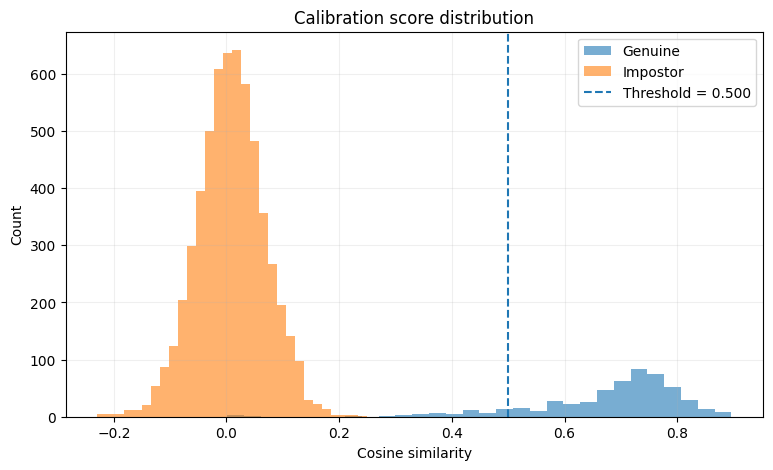

In [17]:
# Cell 17 — Score distribution

plt.figure(figsize=(9, 5))
plt.hist(genuine_scores, bins=30, alpha=0.6, label="Genuine")
plt.hist(impostor_scores, bins=30, alpha=0.6, label="Impostor")
plt.axvline(CONFIG.face_threshold, linestyle="--", label=f"Threshold = {CONFIG.face_threshold:.3f}")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Calibration score distribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [18]:
# Cell 18 — BETTER Held-Out Test


def make_test_sessions(items):

    items = list(items)

    if len(items) < (
        CONFIG.verification_min_good_frames
    ):
        return []

    sessions = []

    for start in range(
        0,
        len(items),
        CONFIG.verification_target_frames
    ):

        chunk = items[
            start:
            start
            + CONFIG.verification_target_frames
        ]

        if len(chunk) >= (
            CONFIG.verification_min_good_frames
        ):

            sessions.append(chunk)

    return sessions


def final_test_session_data(
    dev_data,
    final_test_data
):

    # --------------------------------------------------
    # Build templates ONLY from development data.
    # Held-out data is never used for enrollment.
    # --------------------------------------------------

    templates = {}

    for identity, items in sorted(
        dev_data.items()
    ):

        templates[identity], _ = (
            make_template(items)
        )


    genuine_sessions = []
    impostor_sessions = []


    identities = sorted(
        templates
    )


    for identity in identities:

        test_items = (
            final_test_data
            .get(
                identity,
                []
            )
        )

        sessions = (
            make_test_sessions(
                test_items
            )
        )


        for session in sessions:

            # Genuine
            genuine_sessions.append([

                cosine_similarity(
                    item["embedding"],
                    templates[identity]
                )

                for item in session
            ])


            # Impostor comparisons
            for other in identities:

                if other == identity:
                    continue

                impostor_sessions.append([

                    cosine_similarity(
                        item["embedding"],
                        templates[other]
                    )

                    for item in session
                ])


    return (
        genuine_sessions,
        impostor_sessions
    )


(
    test_genuine_sessions,
    test_impostor_sessions
) = final_test_session_data(
    dev_data,
    final_test_data
)


final_test = (
    session_threshold_metrics(
        test_genuine_sessions,
        test_impostor_sessions,
        CONFIG.face_threshold
    )
)


print()
print("=" * 50)
print("FINAL HELD-OUT TEST")
print("=" * 50)

print(
    "Genuine sessions:",
    len(test_genuine_sessions)
)

print(
    "Impostor sessions:",
    len(test_impostor_sessions)
)

print(
    "Threshold:",
    round(
        CONFIG.face_threshold,
        3
    )
)

print(
    "TPR:",
    f"{final_test['TPR']:.2%}"
)

print(
    "TNR:",
    f"{final_test['TNR']:.2%}"
)

print(
    "FAR:",
    f"{final_test['FAR']:.2%}"
)

print(
    "FRR:",
    f"{final_test['FRR']:.2%}"
)

print(
    "Accuracy:",
    f"{final_test['accuracy']:.2%}"
)

print(
    "Balanced accuracy:",
    f"{final_test['balanced_accuracy']:.2%}"
)


FINAL HELD-OUT TEST
Genuine sessions: 6
Impostor sessions: 66
Threshold: 0.5
TPR: 100.00%
TNR: 100.00%
FAR: 0.00%
FRR: 0.00%
Accuracy: 100.00%
Balanced accuracy: 100.00%


## Live camera test

These cells are for local validation in Colab. In the integrated application, the frontend captures frames and passes them to the same ML functions.

In [19]:
# Cell 19 — Live enrollment test

TEST_STUDENT_ID = "TEST-001"
TEST_FULL_NAME = "Test Member"

registration_data = camera_capture(
    num_frames=CONFIG.registration_target_frames,
    interval_ms=450,
    instruction="REGISTRATION — keep your face centered"
)

registration_frames = camera_frames_to_images(registration_data)
registration_result = enroll_student_from_frames(
    TEST_STUDENT_ID,
    TEST_FULL_NAME,
    registration_frames
)

template_store.save(
    TEST_STUDENT_ID,
    TEST_FULL_NAME,
    registration_result["reference_embedding"],
    registration_result["samples_used"]
)

print(json.dumps({
    "success": registration_result["success"],
    "student_id": registration_result["student_id"],
    "samples_used": registration_result["samples_used"],
    "embedding_dimension": registration_result["embedding_dimension"]
}, indent=2))

<IPython.core.display.Javascript object>

{
  "success": true,
  "student_id": "TEST-001",
  "samples_used": 5,
  "embedding_dimension": 512
}


In [20]:
# Cell 20 — BETTER Live Attendance Test


attendance_data = camera_capture(

    num_frames=50,

    interval_ms=100,

    instruction=(
        "ATTENDANCE — "
        "keep eyes open first, "
        "blink once, then open eyes"
    )
)


attendance_frames = (
    camera_frames_to_images(
        attendance_data
    )
)


attendance_result = (
    verify_attendance_from_frames(

        TEST_STUDENT_ID,

        attendance_frames
    )
)


print(
    json.dumps(
        attendance_result,
        indent=2
    )
)

<IPython.core.display.Javascript object>

{
  "verified": false,
  "student_id": "TEST-001",
  "full_name": "Test Member",
  "similarity": null,
  "threshold": 0.5000000000000002,
  "blink_detected": false,
  "liveness": {
    "enabled": true,
    "passed": false,
    "method": "blink_challenge",
    "status": "failed",
    "reason": "No complete open-close-open blink sequence detected"
  },
  "reason": "Blink challenge failed"
}


In [21]:
# Cell 21 — Wrong-person check

WRONG_ID = "TEST-002"
WRONG_NAME = "Second Test Member"

second_data = camera_capture(
    num_frames=CONFIG.registration_target_frames,
    interval_ms=450,
    instruction="SECOND PERSON — registration test"
)

second_frames = camera_frames_to_images(second_data)
second_result = enroll_student_from_frames(
    WRONG_ID,
    WRONG_NAME,
    second_frames
)

template_store.save(
    WRONG_ID,
    WRONG_NAME,
    second_result["reference_embedding"],
    second_result["samples_used"]
)

wrong_data = camera_capture(
    num_frames=50,
    interval_ms=100,
    instruction="ATTENDANCE — test wrong-person rejection"
)
wrong_frames = camera_frames_to_images(wrong_data)
wrong_result = verify_attendance_from_frames(
    TEST_STUDENT_ID,
    wrong_frames
)

print(json.dumps(wrong_result, indent=2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "verified": false,
  "student_id": "TEST-001",
  "full_name": "Test Member",
  "similarity": null,
  "threshold": 0.5000000000000002,
  "blink_detected": false,
  "liveness": {
    "enabled": true,
    "passed": false,
    "method": "blink_challenge",
    "status": "failed",
    "reason": "No complete open-close-open blink sequence detected"
  },
  "reason": "Blink challenge failed"
}


## API handoff

The functions to expose through FastAPI are:

```python
enroll_student_from_frames(student_id, full_name, frames)
verify_attendance_from_frames(student_id, frames)
```

The API wrapper should receive frames from the backend/frontend and return the ML result. Attendance records, PostgreSQL, session rules, and UI are outside this notebook.

Before deployment, run the live wrong-person test and the blink challenge test with real society members. The current threshold `0.23` is the validated value for the current calibration dataset, not a universal threshold.